# Figure6: plotting and resource-data code

This notebook contains the original figure-production cells. Inputs are under `data/Figure6/`; outputs may be written to `output/`.

## Resource-data sheets included for this figure

- `Figure_6a_in_vitro_killing_efficiency` — resource-data sheet for the corresponding panel.
- `Figure_6c_e_OT1_CX3CR1_flow_cytometry_ratios` — resource-data sheet for the corresponding panel.

The final resource tables use `NR` as the non-responder label. The original analysis cells are retained so that their complete plotting logic is traceable.

In [4]:
# Harmonize standalone response labels at input time: PR -> NR.
harmonize_nr_labels <- function(x) {
  normalize_df <- function(df) {
    for (nm in names(df)) {
      if (is.character(df[[nm]]) || is.factor(df[[nm]])) {
        df[[nm]] <- gsub("\bPR\b", "NR", as.character(df[[nm]]), perl = TRUE)
      }
    }
    df
  }
  if (is.data.frame(x)) return(normalize_df(x))
  if (isS4(x) && "meta.data" %in% slotNames(x)) {
    x@meta.data <- normalize_df(x@meta.data)
  }
  x
}


## Figure_6a

group1,group2,comparison_order,n1,n2,statistic_t,degrees_of_freedom,p_raw,p_adj,label,y.position
<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
CX3CR1+ CD8 T,CX3CR1- CD8 T,1,3,3,3.263776,2.542648,0.029697698,0.02969770,0.030,1.18
CX3CR1+ CD8 T,TCM,2,3,3,4.496452,2.363970,0.016736669,0.02510500,0.025,1.30
CX3CR1+ CD8 T,Naïve CD8 T,3,3,3,6.120387,2.677970,0.006046505,0.01813951,0.018,1.42


Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.


agg_record_2097779349 
                    2

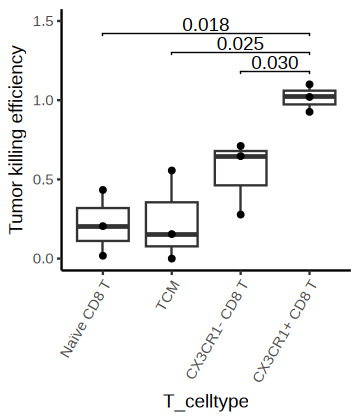

In [5]:
# Figure 6a plotting code
# Organized input location: data/Figure6/

library(data.table)
library(ggplot2)
library(ggpubr)

plot_data <- fread(
  '../data/Figure6/CX3CR1_killing_plot_data_705.tsv',
  sep = '\t'
)

plot_data$T_celltype <- factor(
  plot_data$T_celltype,
  levels = c(
    'Naïve CD8 T',
    'TCM',
    'CX3CR1- CD8 T',
    'CX3CR1+ CD8 T'
  )
)

my_comp <- list(
  c('CX3CR1+ CD8 T', 'CX3CR1- CD8 T'),
  c('CX3CR1+ CD8 T', 'TCM'),
  c('CX3CR1+ CD8 T', 'Naïve CD8 T')
)

# Three prespecified one-sided t-tests followed by one BH correction family.
fig6a_stats <- rbindlist(lapply(seq_along(my_comp), function(i) {
  comparison <- my_comp[[i]]
  x1 <- plot_data[T_celltype == comparison[1], killing_efficiency]
  x2 <- plot_data[T_celltype == comparison[2], killing_efficiency]
  test <- t.test(x1, x2, alternative = 'greater')
  data.table(
    group1 = comparison[1],
    group2 = comparison[2],
    comparison_order = i,
    n1 = length(x1),
    n2 = length(x2),
    statistic_t = unname(test$statistic),
    degrees_of_freedom = unname(test$parameter),
    p_raw = test$p.value
  )
}))
fig6a_stats[, p_adj := p.adjust(p_raw, method = 'BH')]
fig6a_stats[, label := ifelse(
  p_adj < 0.001,
  formatC(p_adj, format = 'e', digits = 2),
  formatC(p_adj, format = 'f', digits = 3)
)]
fig6a_stats[, y.position := c(1.18, 1.30, 1.42)]
fig6a_stats

options(repr.plot.width = 3, repr.plot.height = 3.5)

p <- ggplot(
  plot_data,
  aes(x = T_celltype, y = killing_efficiency)
) +
  geom_boxplot(outlier.shape = NA) +
  geom_dotplot(
    binaxis = 'y',
    stackdir = 'center',
    dotsize = 0.7
  ) +
  ylab('Tumor killing efficiency') +
  theme_classic() +
  theme(
    axis.text.x = element_text(
      angle = 60,
      vjust = 1,
      hjust = 1
    )
  ) +
  stat_pvalue_manual(
    as.data.frame(fig6a_stats),
    xmin = 'group1',
    xmax = 'group2',
    y.position = 'y.position',
    label = 'label',
    tip.length = 0.01
  ) +
  coord_cartesian(ylim = c(0, 1.5))

p

pdf('../output/fig6a-in vitro killing.pdf', width = 3, height = 3.5)
print(p)
dev.off()


## Figure_6e

Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.
Bin width defaults to 1/30 of the range of the data. Pick better value with `binwidth`.


agg_record_283488055 
                   2

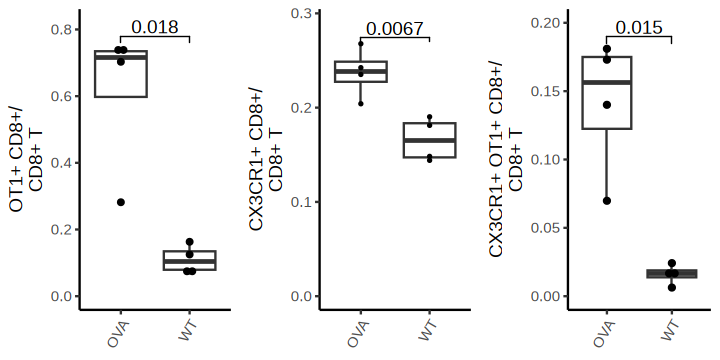

In [6]:
# Figure 6e plotting code
# Organized input location: data/Figure6/

library(data.table)
library(ggplot2)
library(ggpubr)

plot_data <- fread(
  "../data/Figure6/sorting_plot_data.tsv",
  sep = "\t"
)

# 设置横轴顺序
plot_data[, tumor := factor(
  tumor,
  levels = c("OVA", "WT")
)]

make_boxplot <- function(
  data,
  metric_name,
  y_label,
  y_limit
) {
  ggplot(
    data[metric == metric_name],
    aes(
      x = tumor,
      y = value
    )
  ) +
    geom_boxplot(
      outlier.shape = NA
    ) +
    geom_dotplot(
      binaxis = "y",
      stackdir = "center",
      dotsize = 0.7
    ) +
    ylab(y_label) +
    xlab(NULL) +
    theme_classic() +
    theme(
      axis.text.x = element_text(
        angle = 60,
        vjust = 1,
        hjust = 1
      )
    ) +
    stat_compare_means(
      comparisons = list(
        c("OVA", "WT")
      ),
      method = "t.test"
    ) +
    coord_cartesian(
      ylim = y_limit
    )
}

options(
  repr.plot.width = 6,
  repr.plot.height = 6
)

tmp1 <- make_boxplot(
  data = plot_data,
  metric_name = "CX3CR1_OT1_over_OT1",
  y_label = "CX3CR1+ OT1+ CD8+/\nOT1+ CD8+",
  y_limit = c(0, 0.27)
)

tmp2 <- make_boxplot(
  data = plot_data,
  metric_name = "CX3CR1_OT1_over_CX3CR1",
  y_label = "CX3CR1+ OT1+ CD8+/\nCX3CR1+ CD8+",
  y_limit = c(0, 0.82)
)

tmp3 <- make_boxplot(
  data = plot_data,
  metric_name = "CX3CR1_over_CD8",
  y_label = "CX3CR1+ CD8+/\nCD8+ T",
  y_limit = c(0, 0.29)
)

tmp4 <- make_boxplot(
  data = plot_data,
  metric_name = "OT1_over_CD8",
  y_label = "OT1+ CD8+/\nCD8+ T",
  y_limit = c(0, 0.82)
)

tmp5 <- make_boxplot(
  data = plot_data,
  metric_name = "CX3CR1_OT1_over_CD8",
  y_label = "CX3CR1+ OT1+ CD8+/\nCD8+ T",
  y_limit = c(0, 0.20)
)

options(
  repr.plot.width = 6,
  repr.plot.height = 3
)

combined_plot <- ggarrange(
  tmp4,
  tmp3,
  tmp5,
  nrow = 1,
  ncol = 3
)

combined_plot

pdf('../output/fig6c-in-vivo.pdf', width = 3, height = 3.5)
print(p)
dev.off()

## Export the final core resource data